# Hotel Booking Data Analysis
Exploratory data analysis of hotel booking records covering cancellations, guest behaviour, and booking patterns across City and Resort Hotels.

## 1. Import Libraries and Load Data

In [1]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set(style="whitegrid")

df = pd.read_csv("hotel_booking.csv")
display(df.head(3))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01/07/2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01/07/2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02/07/2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.\n")

Dataset contains 119,390 rows and 36 columns.



## 2. Data Cleaning

### 2.1 Find Missing Values and Handle Them

In [9]:
empty = df.isna().sum()
empty_percent = (empty / len(df) * 100).round(2)
print(pd.DataFrame({'empty_count': empty, 'percentage': empty_percent})
      .query('empty_count > 0')
      .sort_values('empty_count', ascending=False))

# company and agent are numeric IDs where NaN means no agent/company was used
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)
# country filled with 'Unknown' to retain rows rather than drop them
df['country'] = df['country'].fillna('Unknown')
# children NaN almost certainly means 0 children
df['children'] = df['children'].fillna(0)

print("Remaining missing values:", df.isna().sum().sum())
display(df.head())

          empty_count  percentage
company        112593       94.31
agent           16340       13.69
country           488        0.41
children            4        0.00
Remaining missing values: 0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01/07/2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01/07/2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02/07/2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02/07/2015,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,03/07/2015,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 2.2 Remove Duplicates

In [12]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]:,} duplicate rows. Remaining: {df.shape[0]:,}")

Removed 0 duplicate rows. Remaining: 119,390


### 2.3 Remove Personally Identifiable Information (PII)

In [13]:
personal_data = ['name', 'email', 'phone-number', 'credit_card']
df = df.drop(columns=personal_data)
print(f"Dropped PII columns: {personal_data}")

display(df.head(3))

Dropped PII columns: ['name', 'email', 'phone-number', 'credit_card']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,02/07/2015


### 2.4 Handle Outliers

In [15]:
# ADR values above 520 are extreme outliers and likely data entry errors.
# Including them would distort distributions and make visualisations unreadable.
df = df[df['adr'] <= 520]
print(f"After removing ADR outliers (> 520): {df.shape[0]:,} rows remain.")

After removing ADR outliers (> 520): 119,389 rows remain.


### 2.5 Remove Invalid/Incorrect Rows
Removing rows with no guests, children or babies with no adults, and negative ADR values.

In [20]:
# Bookings with zero guests across all categories are invalid records
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

# Children or babies with no adults are likely data entry errors
df = df[~((df['adults'] == 0) & ((df['children'] != 0) | (df['babies'] != 0)))]

# Negative ADR has no meaningful interpretation
df = df[df['adr'] >= 0]

print("After Data Cleaning:")
print(f"{df.shape[0]:,} rows and {df.shape[1]} columns\n")

After Data Cleaning:
118,985 rows and 32 columns



## 3. Feature Engineering
Creating new columns to better capture booking characteristics.

In [22]:
# Total nights stayed across weekdays and weekends
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total number of guests across all age groups
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Family flag: 1 if the booking includes at least one child or baby
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

df[['total_stay_nights', 'total_guests', 'is_family']].head()

,total_stay_nights,total_guests,is_family
0,0,2.0,0
1,0,2.0,0
2,1,1.0,0
3,1,1.0,0
4,2,2.0,0


## 4. Univariate Analysis


### 4.1 Lead Time Distribution

How far in advance do customers typically book?

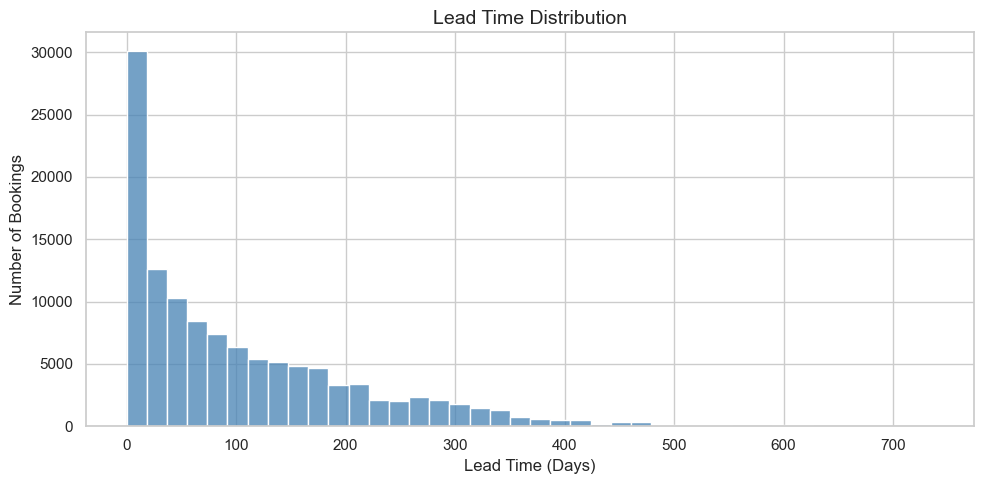

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['lead_time'], bins=40, color='steelblue', edgecolor='white')
plt.title("Lead Time Distribution", fontsize=14)
plt.xlabel("Lead Time (Days)", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** The distribution is heavily right-skewed. Most bookings are made within 100 days of arrival, with a long tail extending past 300 days.

**Insight:** The majority of guests plan relatively close to their arrival date. The long tail of very early bookings is interesting because, as we'll see in the bivariate section, this segment also has the highest cancellation rate — suggesting that distant future plans are the most uncertain.

### 4.2 Total Stay Nights Distribution

How long do guests typically stay?

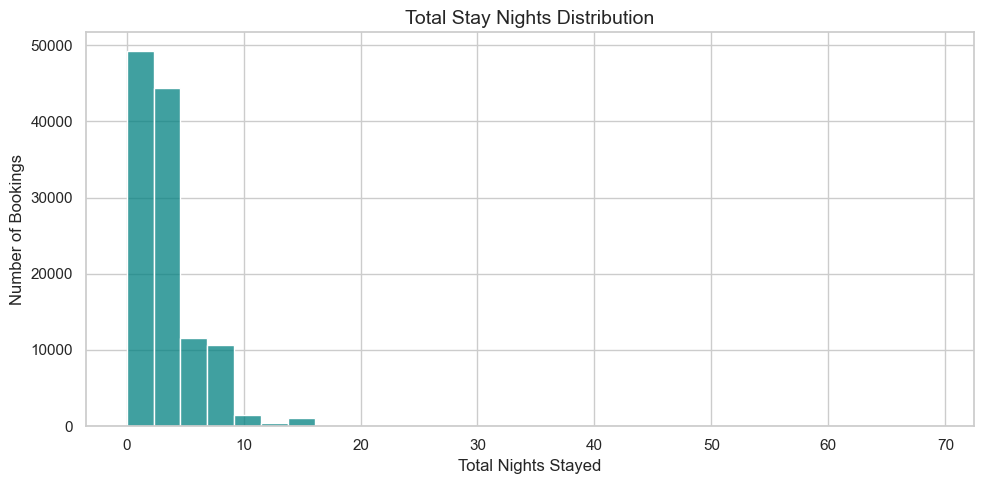

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_stay_nights'], bins=30, color='teal', edgecolor='white')
plt.title("Total Stay Nights Distribution", fontsize=14)
plt.xlabel("Total Nights Stayed", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** The vast majority of stays fall between 1 and 5 nights, with a sharp drop-off after that. Long stays of 15+ nights are very rare.

**Insight:** These are primarily short-stay, transient guests. Operations, staffing, and pricing should be optimised around this profile rather than extended stays.

### 4.3 Total Guests per Booking
How many guests are typically in a booking?

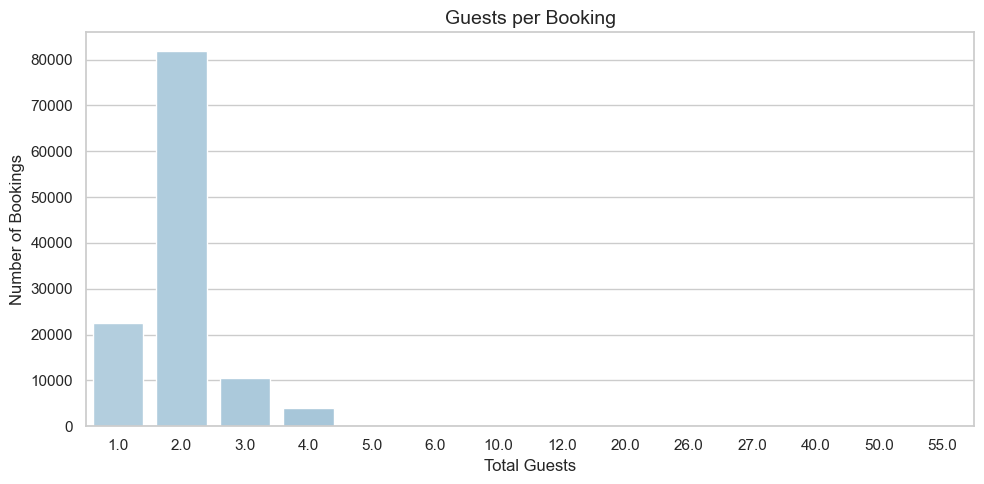

In [35]:
plt.figure(figsize=(10, 5))
guest_order = sorted(df['total_guests'].unique())
sns.countplot(x='total_guests', hue='total_guests', data=df, palette='Blues_d', order=guest_order, legend=False)
plt.title("Guests per Booking", fontsize=14)
plt.xlabel("Total Guests", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** 2-guest bookings are by far the most common, followed by solo travellers and 3-guest groups. Bookings with 4+ guests drop off sharply.

**Insight:** The hotel predominantly serves pairs — most likely couples or business travel partners. Room configuration and package design should reflect this.

### 4.4 Country Distribution (Top 10)

Which countries do most guests come from?


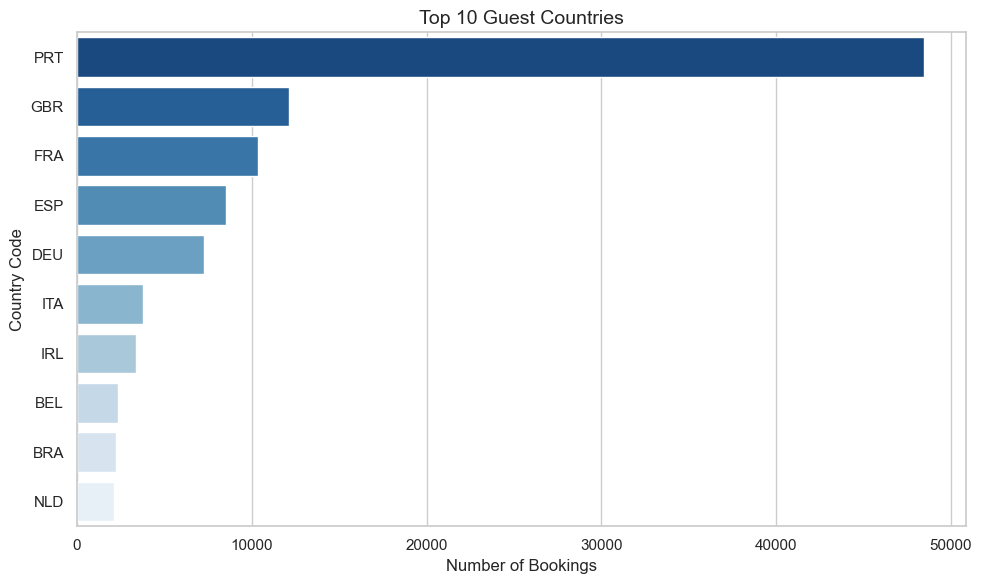

In [34]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Blues_r', legend=False)

plt.title("Top 10 Guest Countries", fontsize=14)
plt.xlabel("Number of Bookings", fontsize=12)
plt.ylabel("Country Code", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** Portugal (PRT) dominates with nearly four times as many bookings as the next country. The UK, France, Spain, and Germany round out the top five.

**Insight:** There is a very strong domestic market. European guests account for the overwhelming majority of international bookings. Targeted marketing in these five countries — with localised content and offers — would likely yield the highest return.

## 5. Bivariate Analysis


### 5.1 Lead Time vs Cancellation

Do guests who book further in advance cancel more often?

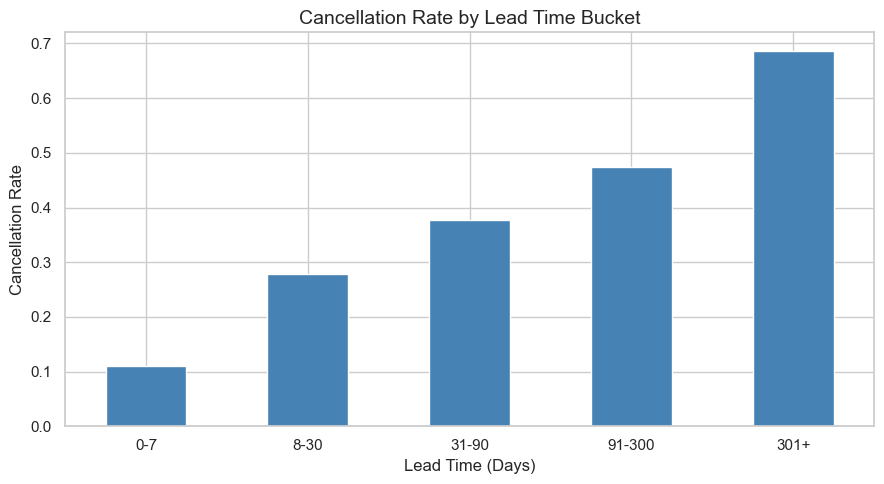

In [39]:

intervals = [0, 7, 30, 90, 300, 700]
labels = ['0-7', '8-30', '31-90', '91-300', '301+']
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=intervals, labels=labels)

cancellation_rate = df.groupby('lead_time_bin')['is_canceled'].mean()

plt.figure(figsize=(9, 5))
cancellation_rate.plot(kind='bar', color='steelblue', edgecolor='white', rot=0)
plt.xlabel('Lead Time (Days)', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.title('Cancellation Rate by Lead Time Bucket', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
# Breakdown by hotel type
df.groupby(['hotel', 'lead_time_bin'])['is_canceled'].mean().unstack().round(2)

lead_time_bin,0-7,8-30,31-90,91-300,301+
hotel,,,,,
City Hotel,0.14,0.31,0.40,0.52,0.75
Resort Hotel,0.07,0.22,0.32,0.39,0.43


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9464\2634401245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


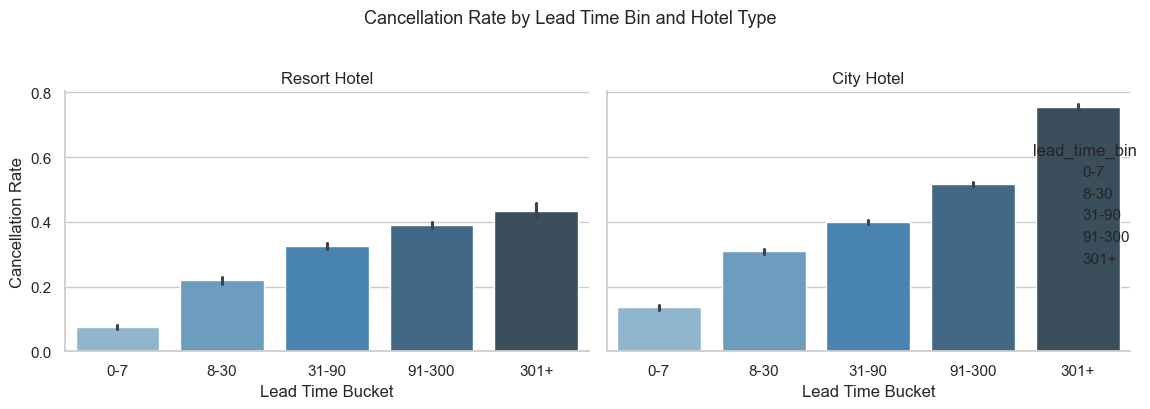

In [47]:
# Catplot: cancellation rate by lead time bin, split by hotel type

g = sns.catplot(
    data=df,
    x='lead_time_bin',
    y='is_canceled',
    col='hotel',
    kind='bar',
    height=4,
    aspect=1.3,
    palette='Blues_d'
)
g.set_axis_labels('Lead Time Bucket', 'Cancellation Rate')
g.set_titles(col_template='{col_name}')
plt.suptitle('Cancellation Rate by Lead Time Bin and Hotel Type', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Cancellation rates climb steadily with lead time across both hotel types. Bookings made within 7 days cancel at just 14% (City) and 7% (Resort). At 301+ days, this jumps to 75% for City Hotel and 43% for Resort Hotel. The gap between the two hotels widens significantly as lead time increases.

**Insight:** The further out a booking is made, the less committed the guest is. City Hotel is disproportionately exposed to this risk. Both hotels should consider deposit requirements or confirmation prompts for bookings made beyond 90 days, with City Hotel needing stricter enforcement particularly at the 300+ day range.

### 5.2 Arrival Month vs Cancellation
Does the time of year affect cancellation behaviour?

In [49]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)

df.groupby(['arrival_date_year', 'arrival_date_month'])['is_canceled'].mean().unstack().round(2)

arrival_date_month,January,February,March,April,May,June,July,August,September,October,November,December
arrival_date_year,,,,,,,,,,,,
2015,NaN,NaN,NaN,NaN,NaN,NaN,0.45,0.41,0.41,0.35,0.21,0.33
2016,0.25,0.34,0.31,0.38,0.35,0.40,0.33,0.36,0.37,0.41,0.37,0.36
2017,0.34,0.33,0.34,0.43,0.44,0.43,0.37,0.37,NaN,NaN,NaN,NaN


In [50]:
# Per hotel breakdown by month
df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().unstack().round(2)

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,0.40,0.15
February,0.38,0.26
March,0.37,0.23
April,0.46,0.29
May,0.44,0.29
June,0.45,0.33
July,0.41,0.31
August,0.40,0.33
September,0.42,0.32


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9464\4008199191.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9464\4008199191.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9464\4008199191.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


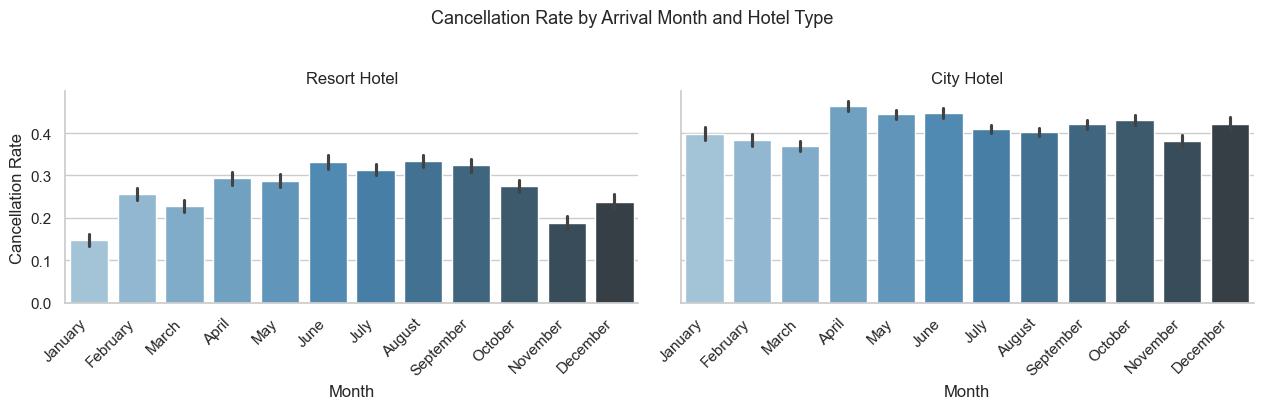

In [63]:
g = sns.catplot(
    data=df,
    x='arrival_date_month',
    y='is_canceled',
    col='hotel',
    kind='bar',
    height=4,
    aspect=1.6,
    palette='Blues_d'
)
g.set_axis_labels('Month', 'Cancellation Rate')
g.set_titles(col_template='{col_name}')
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('Cancellation Rate by Arrival Month and Hotel Type', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [55]:
# Monthly booking volume (to check if high-traffic months also have high cancellation)
monthly_bookings = df.groupby('arrival_date_month').size()
print(monthly_bookings)

arrival_date_month
January       5903
February      8034
March         9749
April        11057
May          11764
June         10917
July         12611
August       13829
September    10489
October      11131
November      6765
December      6736
dtype: int64


**Observation:** Cancellation rates are consistently high throughout the year, mostly in the 30–40% range. There is a slight dip in off-season months like November and January, particularly for Resort Hotel. City Hotel maintains elevated cancellation rates year-round. Months with higher booking volumes also tend to have higher cancellation rates.

**Insight:** Month of arrival is not a strong driver of cancellation on its own. The mild seasonality pattern and persistently high rates across both hotels suggest the issue is structural. It is driven more by booking source and guest type than by when the booking is for. City Hotel's consistently higher rate across all months reinforces this.

### 5.3 Special Requests vs Cancellation

Do guests who make special requests cancel less often?

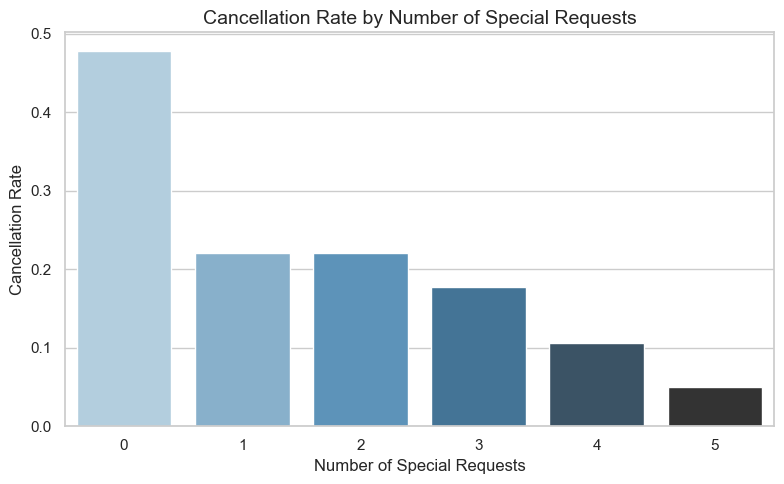

In [58]:
special_req_cancel = df.groupby('total_of_special_requests')['is_canceled'] \
                       .mean() \
                       .reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=special_req_cancel,
    x='total_of_special_requests',
    hue='total_of_special_requests',
    y='is_canceled',
    palette='Blues_d',
    legend=False
)
plt.title("Cancellation Rate by Number of Special Requests", fontsize=14)
plt.xlabel("Number of Special Requests", fontsize=12)
plt.ylabel("Cancellation Rate", fontsize=12)
plt.tight_layout()
plt.show()

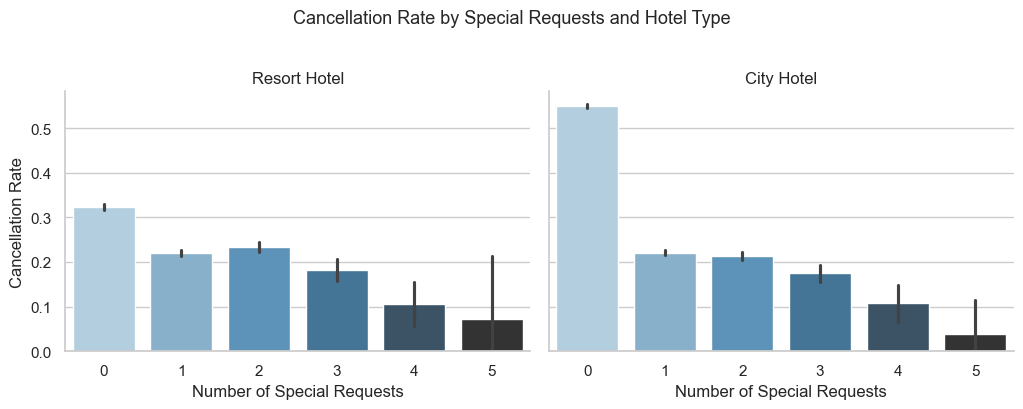

In [60]:
g = sns.catplot(
    data=df,
    x='total_of_special_requests',
    hue='total_of_special_requests',
    y='is_canceled',
    col='hotel',
    kind='bar',
    height=4,
    aspect=1.3,
    palette='Blues_d',
    legend=False
)
g.set_axis_labels('Number of Special Requests', 'Cancellation Rate')
g.set_titles(col_template='{col_name}')
plt.suptitle('Cancellation Rate by Special Requests and Hotel Type', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** There is a clear and consistent downward trend. Every additional special request is associated with a lower cancellation rate. Guests with zero requests cancel at the highest rate, and this pattern holds across both hotel types.

**Insight:** Special requests are a signal of guest commitment. A guest who has taken the time to customise their stay is more invested in it. This can be useful: prompting guests to make at least one special request at booking could act as a low-cost retention mechanism to reduce cancellations.

### 5.4 Hotel Type Analysis

How do City Hotel and Resort Hotel differ across key performance metrics?

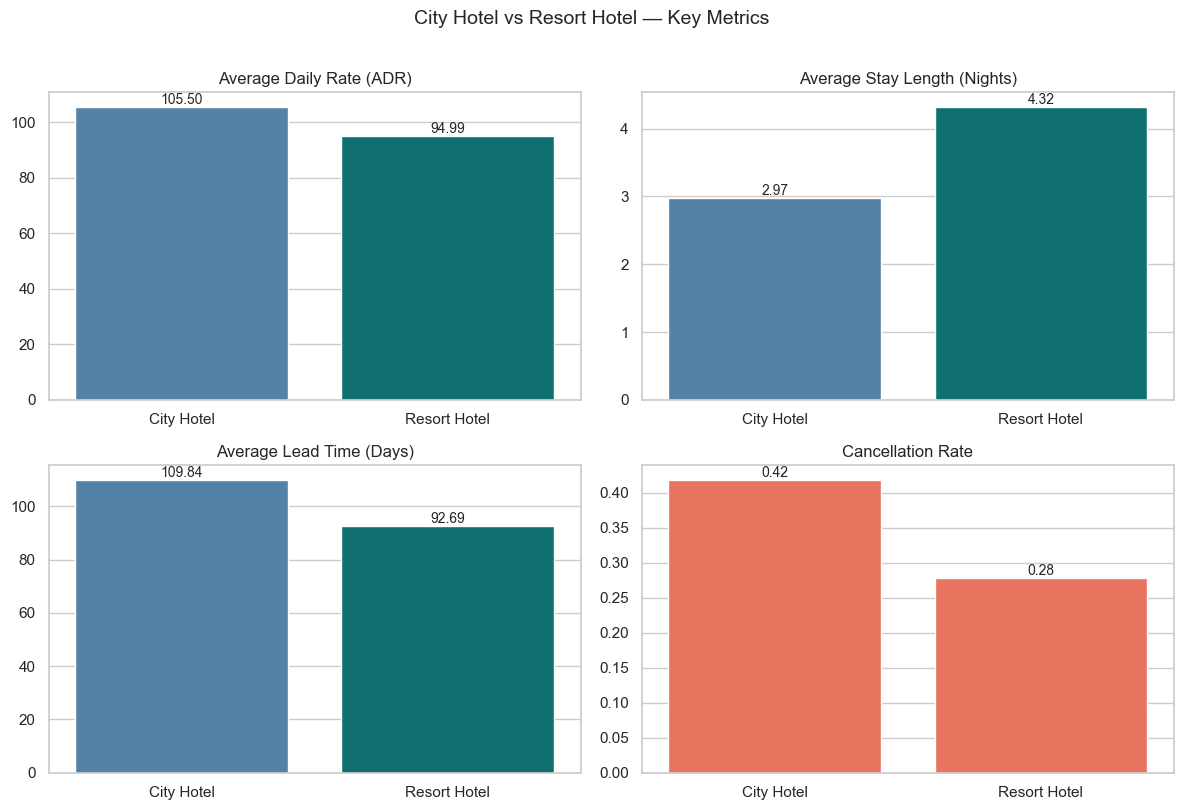

In [69]:
hotel_kpis = df.groupby('hotel').agg(
    avg_adr=('adr', 'mean'),
    avg_stay_nights=('total_stay_nights', 'mean'),
    avg_lead_time=('lead_time', 'mean'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

kpis = [
    ('avg_adr', 'Average Daily Rate (ADR)', ['steelblue', 'teal']),
    ('avg_stay_nights', 'Average Stay Length (Nights)', ['steelblue', 'teal']),
    ('avg_lead_time', 'Average Lead Time (Days)', ['steelblue', 'teal']),
    ('cancellation_rate', 'Cancellation Rate', ['tomato', 'tomato'])
]

for ax, (col, title, palette) in zip(axes.flatten(), kpis):
    sns.barplot(data=hotel_kpis, x='hotel', hue='hotel', y=col, ax=ax, palette=palette,legend=False)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for bar in ax.patches:
        ax.annotate(
            f'{bar.get_height():.2f}',
            (bar.get_x() + bar.get_width() / 2., bar.get_height()),
            ha='center', va='bottom', fontsize=10
        )

plt.suptitle('City Hotel vs Resort Hotel — Key Metrics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

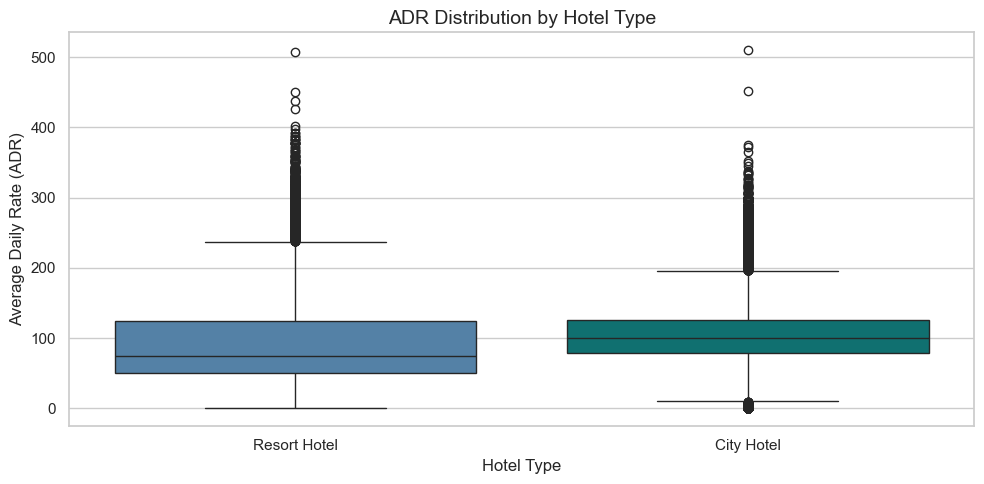

In [76]:
# ADR distribution comparison
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='hotel', hue='hotel', y='adr', palette=['steelblue', 'teal'],legend=False)
plt.title('ADR Distribution by Hotel Type', fontsize=14)
plt.xlabel('Hotel Type', fontsize=12)
plt.ylabel('Average Daily Rate (ADR)', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** City Hotel has a higher average daily rate ($105.50 vs $94.99) but a dramatically higher cancellation rate (42% vs 28%). Resort Hotel guests stay considerably longer on average (4.32 vs 2.97 nights). Lead times are similar between the two, though City Hotel books slightly further out on average.

**Insight:** These are quite different customer profiles. City Hotel attracts higher-paying but less committed guests, likely business travellers or short-break visitors who book early and cancel freely. Resort Hotel guests are more leisure-oriented and stay longer. Revenue management and cancellation policy design should differ meaningfully between the two hotels.

### 5.5 Customer Behaviour Analysis

How does guest profile affect cancellation behaviour?

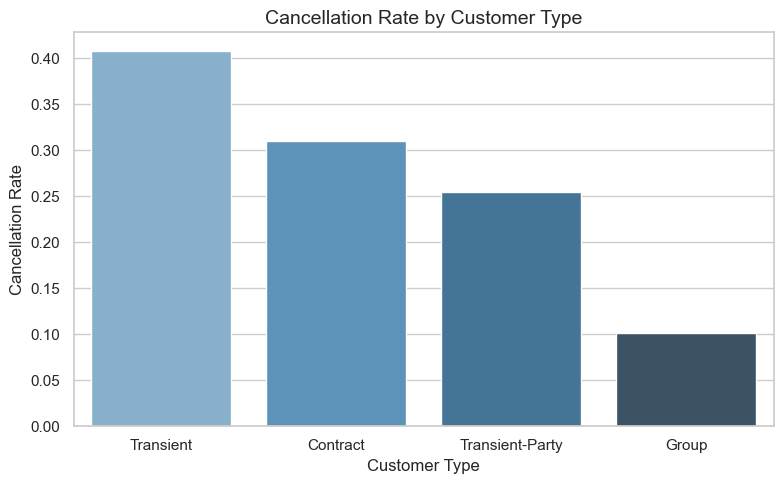

In [80]:
# Customer Type vs Cancellation
customer_cancel = df.groupby('customer_type')['is_canceled'].mean() \
                    .sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=customer_cancel, x='customer_type', hue='customer_type', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate by Customer Type', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

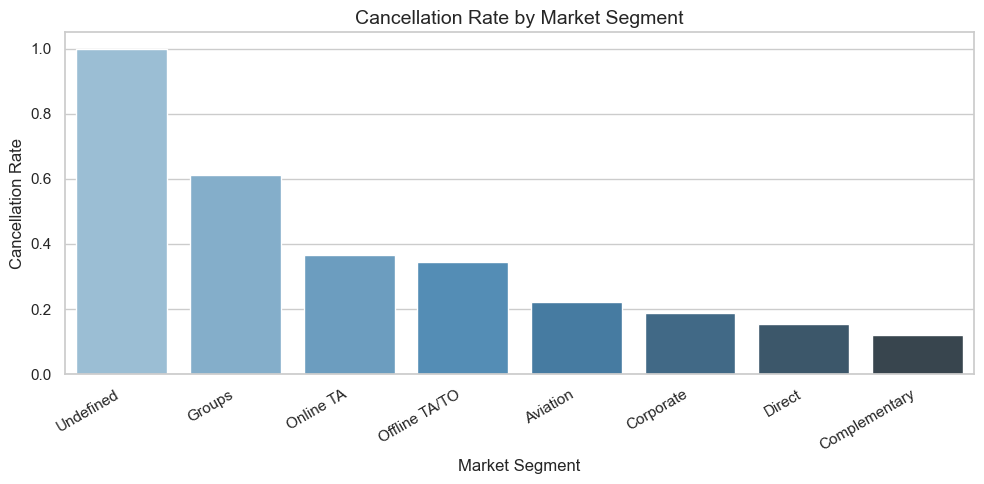

In [83]:
# Market Segment vs Cancellation
market_cancel = df.groupby('market_segment')['is_canceled'].mean() \
                  .sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=market_cancel, x='market_segment', hue='market_segment', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate by Market Segment', fontsize=14)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

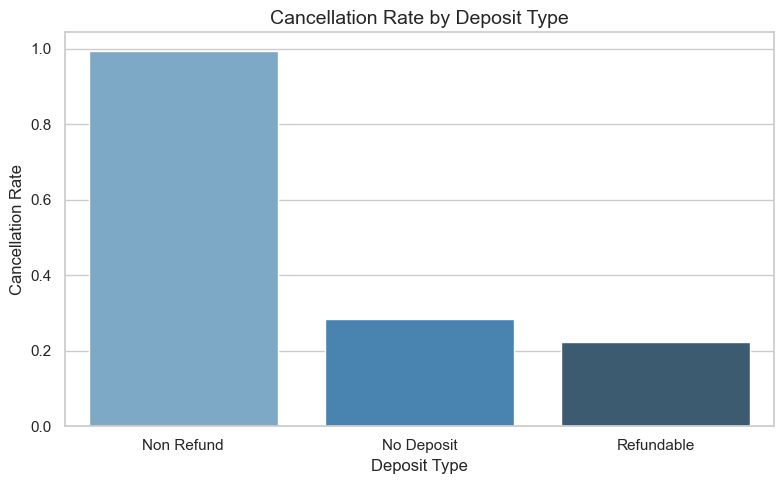

In [85]:
# Deposit Type vs Cancellation
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() \
                   .sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=deposit_cancel, x='deposit_type', hue='deposit_type', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate by Deposit Type', fontsize=14)
plt.xlabel('Deposit Type', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

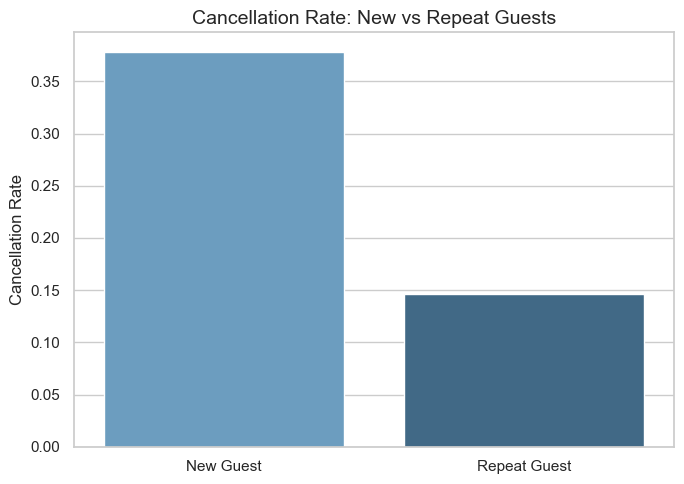

In [88]:
# Repeated Guest vs Cancellation
repeat_cancel = df.groupby('is_repeated_guest')['is_canceled'].mean().reset_index()
repeat_cancel['is_repeated_guest'] = repeat_cancel['is_repeated_guest'].map(
    {0: 'New Guest', 1: 'Repeat Guest'}
)

plt.figure(figsize=(7, 5))
sns.barplot(data=repeat_cancel, x='is_repeated_guest',hue='is_repeated_guest', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate: New vs Repeat Guests', fontsize=14)
plt.xlabel('')
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

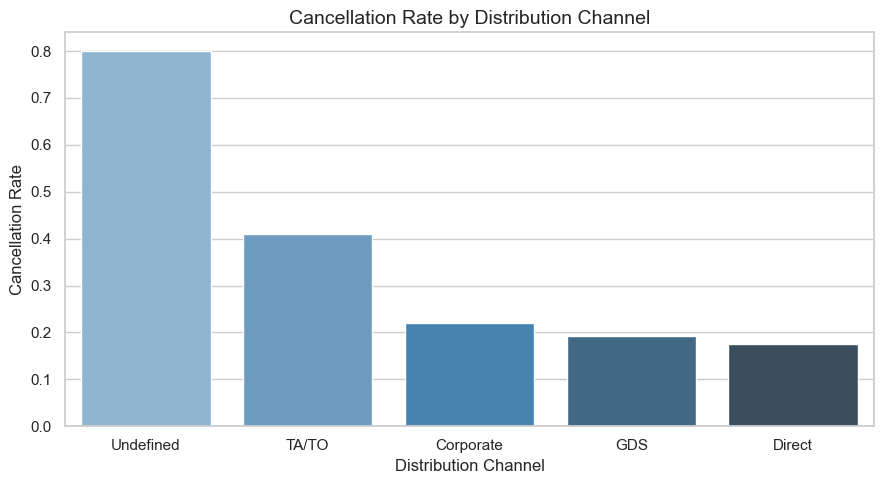

In [95]:
# Distribution Channel vs Cancellation
channel_cancel = df.groupby('distribution_channel')['is_canceled'].mean() \
                   .sort_values(ascending=False).reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=channel_cancel, x='distribution_channel', hue='distribution_channel', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate by Distribution Channel', fontsize=14)
plt.xlabel('Distribution Channel', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:**
1. **Customer Type:** Transient guests have the highest cancellation rate (41%), while Group bookings cancel far less (10%).
2. **Market Segment:** Groups (61%) and Online TA (37%) have the highest cancellation rates. Direct (15%) and Corporate (19%) are the most reliable.
3. **Deposit Type:** Non Refund deposits show a near-100% cancellation rate. Refundable and No Deposit bookings behave more as expected.
4. **Repeated Guests:** Repeat guests cancel at just 15%, compared to 38% for new guests.
5. **Distribution Channel:** TA/TO channel bookings cancel at 41%. Direct bookings are far more reliable at 17%.

**Insight:** Online travel agency and Group bookings represent the highest cancellation risk by segment. New guests are far less reliable than returning ones. Direct bookings and corporate contracts deliver the lowest cancellation rates. This points to a clear priority: invest in direct booking channels and guest loyalty, and apply stricter policies to high-risk OTA and group segments.

### 5.6 Booking Behaviour Analysis

How do specific booking actions relate to whether a guest follows through?

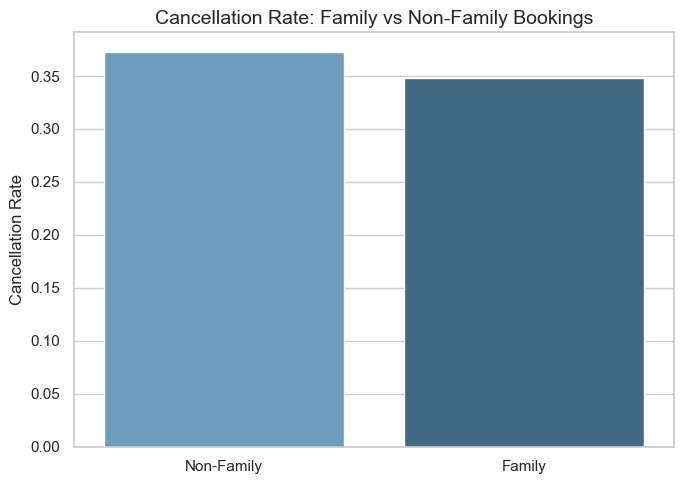

In [96]:
# Family bookings vs Cancellation
family_cancel = df.groupby('is_family')['is_canceled'].mean().reset_index()
family_cancel['is_family'] = family_cancel['is_family'].map({0: 'Non-Family', 1: 'Family'})

plt.figure(figsize=(7, 5))
sns.barplot(data=family_cancel, x='is_family',hue='is_family', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate: Family vs Non-Family Bookings', fontsize=14)
plt.xlabel('')
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

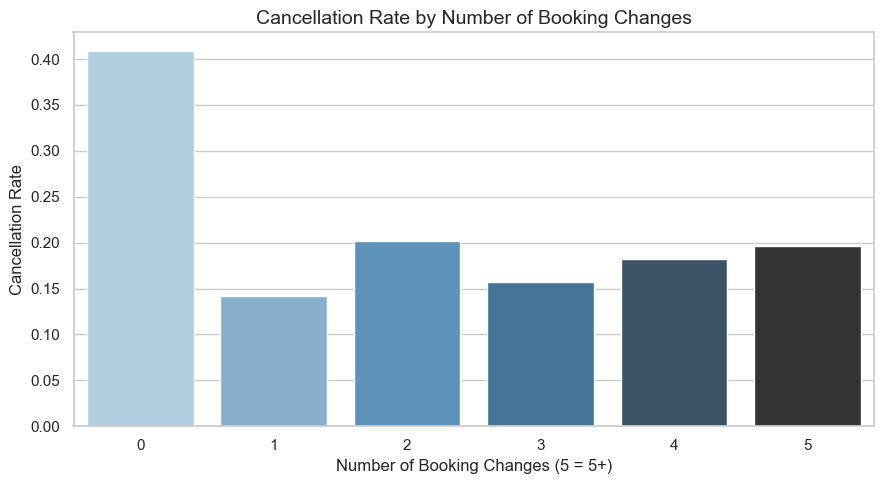

In [97]:
# Booking Changes vs Cancellation
# Cap at 5 for readability (very few bookings have more than 5 changes)
df['booking_changes_capped'] = df['booking_changes'].clip(upper=5)
changes_cancel = df.groupby('booking_changes_capped')['is_canceled'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=changes_cancel, x='booking_changes_capped', hue='booking_changes_capped', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate by Number of Booking Changes', fontsize=14)
plt.xlabel('Number of Booking Changes (5 = 5+)', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

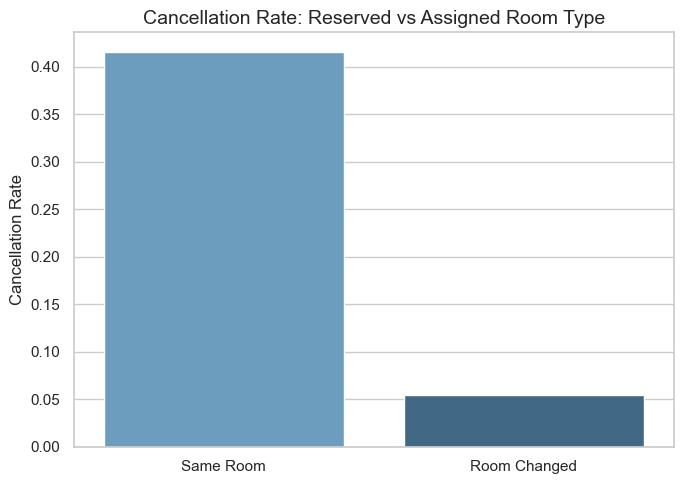

In [98]:
# Reserved vs Assigned Room Type
df['room_type_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

room_cancel = df.groupby('room_type_changed')['is_canceled'].mean().reset_index()
room_cancel['room_type_changed'] = room_cancel['room_type_changed'].map(
    {0: 'Same Room', 1: 'Room Changed'}
)

plt.figure(figsize=(7, 5))
sns.barplot(data=room_cancel, x='room_type_changed', hue='room_type_changed', y='is_canceled', palette='Blues_d',legend=False)
plt.title('Cancellation Rate: Reserved vs Assigned Room Type', fontsize=14)
plt.xlabel('')
plt.ylabel('Cancellation Rate', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:**
1. **Family Bookings:** Family and non-family bookings cancel at nearly the same rate (35% vs 37%). The difference is minimal.
2. **Booking Changes:** Bookings with zero changes cancel most frequently. Even a single modification is associated with a significant drop in cancellation rate — mirroring the special requests pattern.
3. **Room Type Mismatch:** When the assigned room differs from the reserved room, the cancellation rate drops to just 5% vs 42% for same-room bookings. 
Importantly, this is largely because room changes happen at or after check-in. So, this group is almost entirely composed of guests who actually showed up. It confirms the pattern that engaged and present guests are the non-cancelled ones.

**Insight:** Guest engagement — whether through special requests, booking modifications, or simply showing up — consistently separates the cancellers from the arrivals. Family status alone is not a reliable predictor. 

## Key Business Insights

- **Cancellation is primarily driven by lead time and booking channel.** Guests who book far in advance through online travel agencies cancel most frequently. Both factors compound — an OTA booking made 300+ days out is extremely high risk. Deposit requirements and confirmation nudges for this segment are the most direct lever.

- **City Hotel has a structurally higher cancellation rate than Resort Hotel across every segment, month, and lead time bucket.** The gap is largest at long lead times (75% vs 43% at 300+ days). These two hotels serve meaningfully different customer profiles and need different revenue management strategies.

- **Guest engagement signals commitment.** Special requests and booking modifications both correlate strongly with lower cancellation rates, independently of each other. Encouraging at least one interaction post-booking — a preference form, a room request prompt — could reduce cancellations at low cost.

- **Repeat guests and direct bookings are by far the most reliable.** Repeat guests cancel at 15% vs 38% for new guests. Direct channel bookings cancel at 17% vs 41% for TA/TO. Loyalty programmes and direct booking incentives would meaningfully improve the overall booking quality across both hotels.

- **Portugal is the dominant source market, with the UK, France, Spain, and Germany as the key international markets.** These five countries account for a disproportionate share of bookings. Localised campaigns targeting these markets offer the clearest return on marketing spend.

- **Groups are a high-cancellation segment (61% rate) that warrants scrutiny.** Despite being associated with larger booking volumes, groups cancel at nearly twice the rate of transient bookings. Group contracts should include non-refundable elements or at minimum tighter cancellation windows.